# Esame Laboratorio di Programmazione II - 28/08/2025


Scrivete chiaramente sul notebook il vostro nome e matricola e sul nome con cui salvate il file la vostra matricola.

Per ogni funzione e metodo che richiede un campionamento rispetto ad una distribuzione settate il seed a 0: ``np.random.seed(0)``.

Stampate il risultato delle domanda e consegnate il compito eseguito, quindi per cui ogni cella ha il corrispondente output.
Quindi ad esempio

e.g., 
NON scrivete: 
```python 
    lista=np.array([1,2,3])
```
ma 
```python
    lista=np.array([1,2,3]) 
    print('lista =', lista)   
```
Attenzione!Se scrivete:
```python
    lista=np.array([1,2,3])
    lista
```
``lista`` sarà l'unico ouput che si vede di quella cella

NB se l'output è una matrice molto grande non dovete stamparla.

Sarà valutata anche la presentazione, ad esempio un plot senza ettichette sugli assi o illleggibili sarà valutato meno bene di uno con ettichette chiare.

Commentate il compito di modo che si capisca cosa avete fatto.

Controllate attentamente di avere consegnato il file giusto.

In [1]:
#Potete importare direttamente qui le librerie che userete
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Esercizio 1

Supponiamo che i seguenti valori rappresentino il numero di ore di sonno dormite ogni notte nelle ultime **due settimane**:  
**6.5, 5.0, 7.8, 8.2, 4.9, 6.0, 7.0, 7.5, 6.8, 5.5, 8.0, 6.3, 7.2, 5.8**

1. Inserisci questi valori in un array NumPy

2. Crea un nuovo array che assegna un **punteggio di qualità del sonno** secondo le seguenti regole:
   - `1` se il sonno è **inferiore a 6 ore**
   - `2` se è **tra 6 ore (incluse) e meno di 8 ore**
   - `3` se è **8 ore o più**

3. Calcola la **percentuale di notti** per ciascuna fascia di qualità del sonno:
   - Percentuale di notti con punteggio **1** (meno di 6 ore)
   - Percentuale di notti con punteggio **2** (tra 6 e meno di 8 ore)
   - Percentuale di notti con punteggio **3** (8 ore o più)


In [14]:
ore_sonno = np.array([6.5, 5.0, 7.8, 8.2, 4.9, 6.0, 7.0, 7.5, 6.8, 5.5, 8.0, 6.3, 7.2, 5.8])

qualità = np.where(ore_sonno < 6, 1, np.where(ore_sonno < 8, 2, 3))

percentuale_1 = np.mean(qualità==1)*100
percentuale_2 = np.mean(qualità==2)*100
percentuale_3 = np.mean(qualità==3)*100
print(f"Ore sonno: {ore_sonno}\nQualità: {qualità}\nPercentuali per qualità: {np.array([percentuale_1, percentuale_2, percentuale_3])}")

Ore sonno: [6.5 5.  7.8 8.2 4.9 6.  7.  7.5 6.8 5.5 8.  6.3 7.2 5.8]
Qualità: [2 1 2 3 1 2 2 2 2 1 3 2 2 1]
Percentuali per qualità: [28.57142857 57.14285714 14.28571429]


## Esercizio 2
Un’urna contiene 3 palline rosse e 2 blu. A ogni estrazione si rimette la pallina nell’urna.
Quindi ad esempio la propabilità di estarre una pallina rossa è 3/5.
1. Scrivi una funzione che simula N estrazioni e rappresentale con un array NumPy (1 = rosso, 0 = blu).  Esempio: estrazioni_palline(3) = array([0,0,1])
2. Calcola la proporzione cumulativa di palline rosse dopo 10, 20, 30, …, 100 estrazioni. Siignifica ad esempio che per N estrazioni, contiamo quante volte è uscita una pallina rossa e dividiamo per 10.
3. Fai un grafico dell’andamento della proporzione cumulativa in funzione del numero di estrazioni.



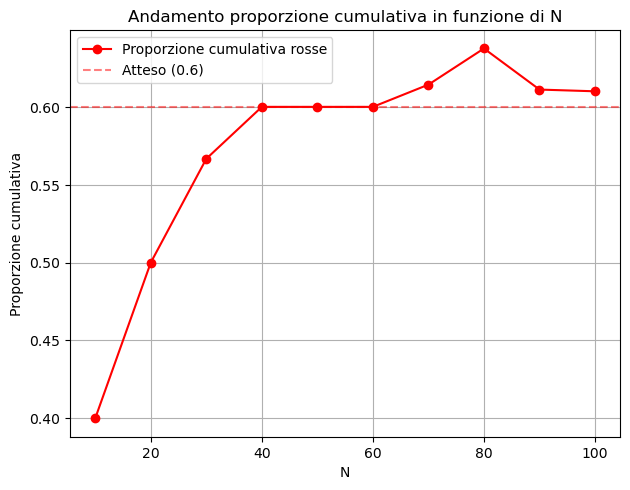

In [18]:
def estrazione(N):
    risultato = np.random.choice([0,1], size = N, p=[2/5,3/5])
    return risultato

risultato = estrazione(100)  # un unico array da 100 estrazioni

intervalli = np.arange(10, 101, 10)
p_cum = [np.mean(risultato[:i]) for i in intervalli]

plt.plot(intervalli, p_cum, color='red', marker='o', label='Proporzione cumulativa rosse')
plt.xlabel('N')
plt.ylabel('Proporzione cumulativa')
plt.grid(True)
plt.tight_layout()
plt.title('Andamento proporzione cumulativa in funzione di N')
plt.axhline(y=3/5, color='red', linestyle='--', alpha=0.5, label='Atteso (0.6)')
plt.legend()
plt.show()

## Esercizio 3

1. Genera una matrice NumPy di dimensioni 8 x 8, con valori interi casuali compresi tra -20 e 20 (inclusi).

2. Per ogni riga, seleziona il numero **più vicino a 10**.

In [20]:
matrice = np.random.randint(-20, 21, size=(8,8))

array = []
for riga in matrice:
    tmp = riga - 10
    idx = np.argmin(abs(tmp))
    valore = riga[idx]
    array.append(valore)

array = np.array(array)

print(f"Matrice: {matrice}\nArray: {array}")

Matrice: [[  0 -17   6   3  -7   1 -20  -1]
 [-18  20 -17  -1  -7   0   4  15]
 [ -3  18  -2  -8  -5   0  17   1]
 [  0  -7  -5 -17   6 -19  -9  17]
 [  9  20   8   5 -17   2  -5  -8]
 [  3 -10  13 -12  -4  17 -18  16]
 [  3  -2   5  -6  16 -19  -1 -17]
 [ -3  -8 -16  -3  12  17  14   2]]
Array: [ 6 15 17  6  9 13  5 12]


## Esercizio 4  

Utilizza il dataset `movies.csv` (contenente colonne come `title`, `budget`, `revenue`, `vote_average`, `vote_count`).  

1. Elimina le righe con i valori mancanti. e **Crea una nuova colonna** `roi` (return on investment), definita come:  

   $$
   \texttt{roi} = \frac{\texttt{revenue} - \texttt{budget}}{\texttt{budget}}
   $$  

   *(Indica di quanto il film ha guadagnato rispetto al costo di produzione).*  

2. Trova i **5 film con ROI più alto** e stampa `title` e `roi`.  

3. **Filtra i film** che hanno:  
   - `budget` > 50 milioni  
   - `vote_average` > 7  

4. **Crea un grafico a barre** con i **10 film con ROI più alto**.  

5. **Crea uno scatter plot** con:  
   - asse x = `budget`  
   - asse y = `revenue`  
   - colore dei punti = `vote_average`  


Cinque film con roi più grande: 
(3608         From Prada to Nada
7447        Paranormal Activity
2449    The Blair Witch Project
3581    Love, Wedding, Marriage
242                 The Gallows
Name: original_title, dtype: str, 3608    26880.720430
7447    12889.386667
2449     9919.000000
3581     1377.000000
242       425.644100
Name: roi, dtype: float64)


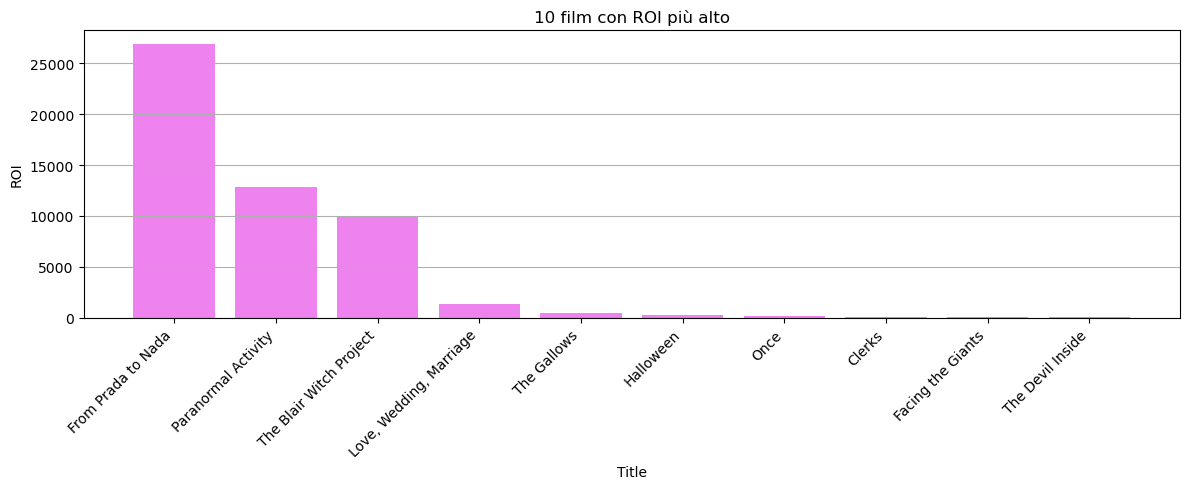

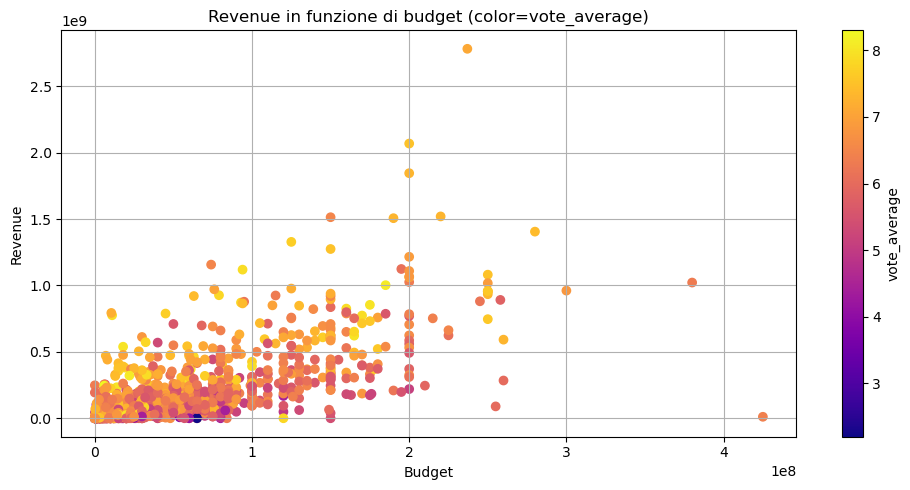

In [9]:
df = pd.read_csv('movies.csv')

# 1
df = df.dropna()
df = df[df['budget'] > 0]
df['roi'] = (df['revenue'] - df['budget'])/df['budget']

# 2
top5 = df.nlargest(5, 'roi')
print(f"Cinque film con roi più grande: \n{top5['original_title'], top5['roi']}")

# 3
df_filtered = df[(df['budget']>50) & (df['vote_average']>7)]

# 4
plt.figure(figsize=(12, 5))
top10 = df.nlargest(10, 'roi')

plt.bar(top10['original_title'], top10['roi'], color='violet')
plt.title('10 film con ROI più alto')
plt.xlabel('Title')
plt.xticks(rotation=45, ha='right')
plt.ylabel('ROI')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# 5
plt.figure(figsize=(10, 5))
scatter = plt.scatter(df['budget'], df['revenue'], c=df['vote_average'], cmap='plasma')
plt.colorbar(scatter, label='vote_average')
plt.title('Revenue in funzione di budget (color=vote_average)')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

## Esercizio 5  

Utilizza il dataset `movies.csv`.  

1. Quante **righe e colonne** ha il dataset? Successivamente elimina la colonna `overview` dal DataFrame.  
2. Trova il **regista** (`director`) che ha diretto il maggior numero di film.  
3. Calcola il **vote_average medio** per ciascun `director` e ordina i primi 10.  
4. Crea un **boxplot** dei valori di `vote_average` raggruppati per `director` (solo i 5 registi con più film).  
5. Crea un **violin plot** della distribuzione dei `vote_average` per genere (`genres`).  


Numero di righe 1446 e numero di colonne 22
Regista con più film: John Carpenter (15 film)
director
Damien Chazelle                                                                 8.2
Morgan Spurlock                                                                 8.0
Tony Kaye                                                                       8.0
Pete Docter                                                                     8.0
Lenny Abrahamson                                                                8.0
Morten Tyldum                                                                   8.0
Jeremy Podeswa|Tim Van Patten|David Nutter|Graham Yost|Carl Franklin|Tony To    7.8
Lilly Wachowski|Lana Wachowski                                                  7.8
Richard Marquand                                                                7.8
Rajkumar Hirani                                                                 7.8
Name: vote_average, dtype: float64


C:\Users\Viola\AppData\Local\Temp\ipykernel_21872\4249004419.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=top5_registi)


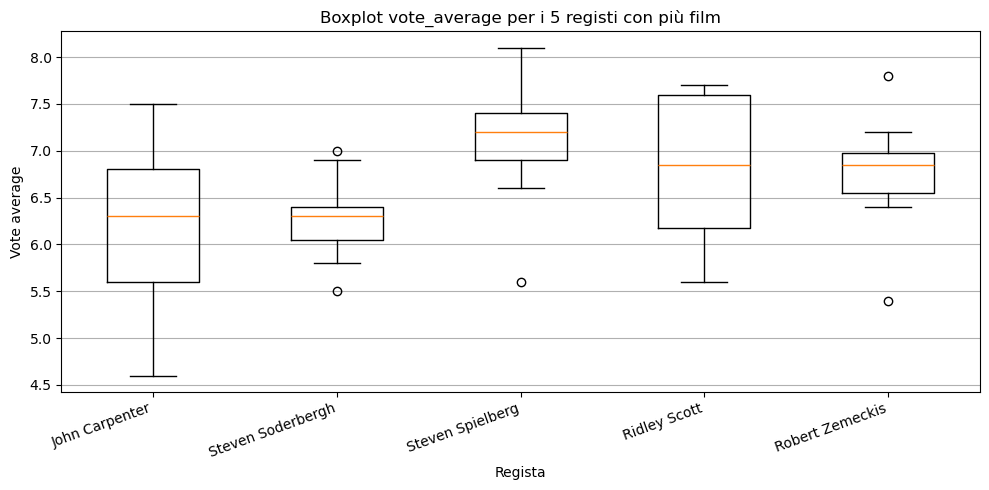

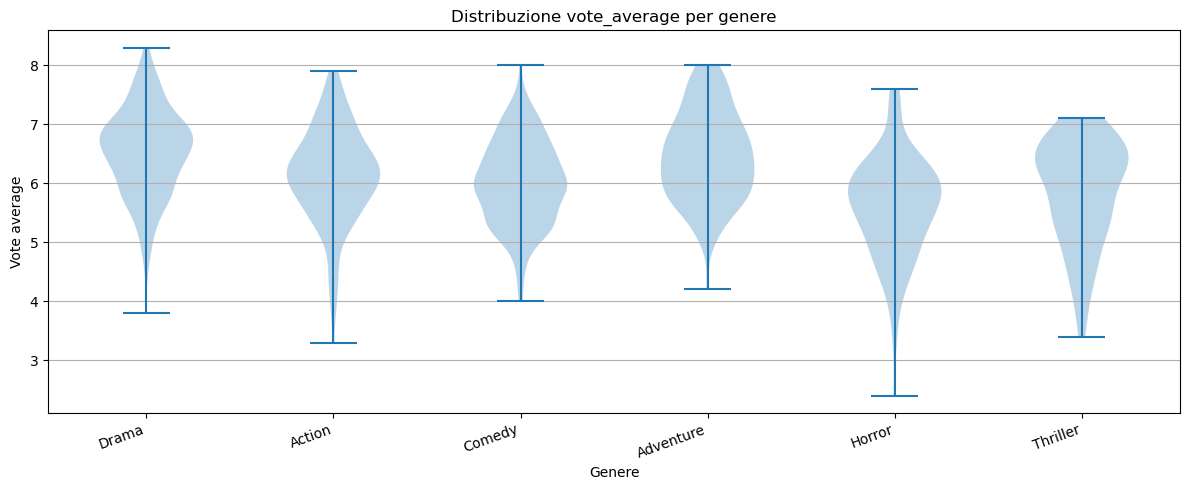

In [11]:
# 1
print(f"Numero di righe {df.shape[0]} e numero di colonne {df.shape[1]}")
df = df.drop(columns=['overview'])
# 2
regista = df['director'].value_counts().idxmax()
n_film = df['director'].value_counts().max()
print(f"Regista con più film: {regista} ({n_film} film)")

# 3
top10 = df.groupby('director')['vote_average'].mean().sort_values(ascending=False).head(10)
print(top10)

# 4
top5_registi = df['director'].value_counts().head(5).index
data = [df[df['director']==r]['vote_average'].values for r in top5_registi]
plt.figure(figsize=(10, 5))
plt.boxplot(data, labels=top5_registi)
plt.title('Boxplot vote_average per i 5 registi con più film')
plt.xlabel('Regista')
plt.ylabel('Vote average')
plt.xticks(rotation=20, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# 5
df['genre_main'] = df['genres'].str.split('|').str[0].str.strip()
generi = df['genre_main'].value_counts().head(6).index
data = [df[df['genre_main'] == g]['vote_average'].dropna().values for g in generi]

plt.figure(figsize=(12, 5))
plt.violinplot(data, positions=range(len(generi)))
plt.xticks(range(len(generi)), generi, rotation=20, ha='right')
plt.title('Distribuzione vote_average per genere')
plt.xlabel('Genere')
plt.ylabel('Vote average')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [10]:
print(df['genres'].head(10))

0    Action|Adventure|Science Fiction|Thriller
1    Action|Adventure|Science Fiction|Thriller
2           Adventure|Science Fiction|Thriller
3     Action|Adventure|Science Fiction|Fantasy
4                        Action|Crime|Thriller
5             Western|Drama|Adventure|Thriller
6    Science Fiction|Action|Thriller|Adventure
7              Drama|Adventure|Science Fiction
8            Family|Animation|Adventure|Comedy
9                      Comedy|Animation|Family
Name: genres, dtype: str


## Esercizio 6  

Hai a disposizione il dataset di coppie `(x, y)`  qui sotto riportato.

1. Usa `scipy.optimize.curve_fit` per stimare i parametri della retta del tipo `y = a * x + b`.  
2. Plotta i punti originali e la retta ottenuta.  
3. Calcola **MAE** e **RMSE** tra i valori reali `y` e quelli stimati dal modello.  


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

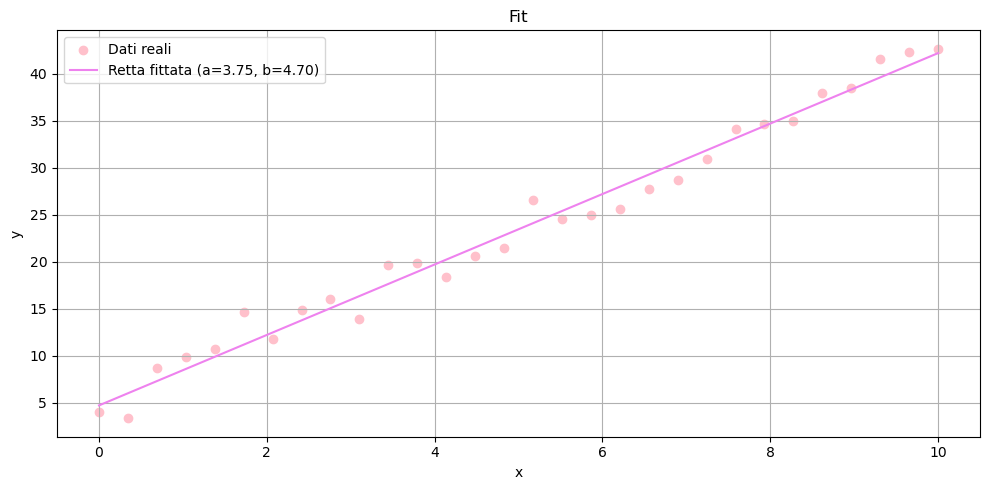

MAE: 1.3703
RMSE: 1.5627


In [2]:
x = np.array([
  0.0, 0.3448, 0.6897, 1.0345, 1.3793, 1.7241,
  2.0690, 2.4138, 2.7586, 3.1034, 3.4483, 3.7931,
  4.1379, 4.4828, 4.8276, 5.1724, 5.5172, 5.8621,
  6.2069, 6.5517, 6.8966, 7.2414, 7.5862, 7.9310,
  8.2759, 8.6207, 8.9655, 9.3103, 9.6552, 10.0
])

y = np.array([
   3.99,  3.33,  8.71,  9.83, 10.69, 14.59,
  11.72, 14.87, 16.06, 13.93, 19.61, 19.83,
  18.40, 20.59, 21.45, 26.51, 24.57, 24.94,
  25.55, 27.78, 28.71, 30.87, 34.14, 34.65,
  35.01, 37.94, 38.53, 41.56, 42.28, 42.65
])
# 1
def retta(x,a,b):
    return a*x + b

params, cov = curve_fit(retta, x, y)
a,b = params

# 2
y_fit = retta(x,a,b)

plt.figure(figsize=(10,5))
plt.scatter(x, y, color='pink', label='Dati reali')
plt.plot(x, y_fit, color='violet', label=f'Retta fittata (a={a:.2f}, b={b:.2f})')
plt.title('Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 3
MAE = np.mean(np.abs(y-y_fit))
RMSE = np.sqrt(np.mean((y-y_fit)**2))

print(f"MAE: {MAE:.4f}")
print(f"RMSE: {RMSE:.4f}")